In [1]:
import openpyxl as oxl
import pandas as pd

In [2]:
wb = oxl.load_workbook("model_export2.xlsx")

In [3]:
wb.sheetnames

['GIM_patients', 'ICU_patients', 'Parameters', 'Dailies', 'Hourlies']

In [4]:
dailies = pd.read_excel(wb, sheet_name="Dailies", engine="openpyxl").set_index("date")["count"]
display(type(dailies))
dailies

pandas.Series

date
2024-09-20    1
2024-09-21    0
2024-09-22    1
2024-09-23    0
2024-09-24    1
             ..
2025-05-23    0
2025-05-24    0
2025-05-25    0
2025-05-26    0
2025-05-27    1
Name: count, Length: 250, dtype: int64

In [5]:
hourlies = pd.read_excel(wb, sheet_name="Hourlies", engine="openpyxl").set_index("hour")["probability"]
display(type(hourlies))
hourlies

pandas.Series

hour
0     0.020696
1     0.008467
2     0.013170
3     0.011289
4     0.011289
5     0.024459
6     0.021637
7     0.020696
8     0.020696
9     0.032926
10    0.067733
11    0.061148
12    0.091251
13    0.060207
14    0.056444
15    0.049859
16    0.063970
17    0.053622
18    0.092192
19    0.050800
20    0.049859
21    0.041392
22    0.038570
23    0.037629
Name: probability, dtype: float64

In [6]:
sum(hourlies)

1.0

In [7]:
# Simulation Parameters
jitter = wb["Parameters"]["B1"].value
jitter

0

In [8]:
wb["GIM_patients"].merged_cells.ranges

{<MergedCellRange M5:M7>,
 <MergedCellRange D5:D7>,
 <MergedCellRange C5:C7>,
 <MergedCellRange A5:A7>,
 <MergedCellRange K5:K7>,
 <MergedCellRange L5:L7>,
 <MergedCellRange J5:J7>,
 <MergedCellRange B5:B7>}

In [9]:
{r.start_cell: r.size['rows'] for r in wb["GIM_patients"].merged_cells.ranges}

{<Cell 'GIM_patients'.M5>: 3,
 <Cell 'GIM_patients'.D5>: 3,
 <Cell 'GIM_patients'.C5>: 3,
 <Cell 'GIM_patients'.A5>: 3,
 <Cell 'GIM_patients'.K5>: 3,
 <Cell 'GIM_patients'.L5>: 3,
 <Cell 'GIM_patients'.J5>: 3,
 <Cell 'GIM_patients'.B5>: 3}

In [10]:
import typing


def read_xlsx_gim(ws: oxl.worksheet.worksheet.Worksheet) -> dict[str, typing.Any]:
    """Parse the GIM patient parameters from the given worksheet.
    
    TODO: validate probabilities sum to 1 for each relevant population, or recalculate them.
    """
    range_sizes = {r.start_cell: r.size['rows'] for r in wb["GIM_patients"].merged_cells.ranges}
    curr_row = 2 # Skip header row
    result = {}
    while True:
        # A{row} is always "GIM"  -- if it's empty, we've reached the end of the table
        if ws[f"A{curr_row}"].value is None:
            break

        label = str(ws[f"B{curr_row}"].value)
        n_patients_label = int(ws[f"C{curr_row}"].value)
        prob_label = float(ws[f"D{curr_row}"].value)
        # columns E to I are per group, we will return to them later
        dist_name = str(ws[f"J{curr_row}"].value)
        dist_params = [float(ws[f"{col}{curr_row}"].value) for col in ["K", "L", "M"]]

        # How many groups are there for this label? Count the number of merged cells in column A
        n_groups = 1
        if f"A{curr_row}" in range_sizes:
            n_groups = range_sizes[f"A{curr_row}"]

        # Read the group-specific parameters from columns E to I
        group_params = {}
        for group_idx in range(n_groups):
            key = (
                "gim",
                str(ws[f"E{curr_row + group_idx}"].value),  # outcome
                str(ws[f"F{curr_row + group_idx}"].value),  # age group
            )
            group_params[f"{key}"] = {
                # Probability of this group in the full patient population (GIM + ICU)
                "p_total": float(ws[f"G{curr_row + group_idx}"].value),
                # Probability of this group among patients with the given label
                "p_in_label": float(ws[f"H{curr_row + group_idx}"].value),
            }
        
        # Advance the current row by the number of groups
        curr_row += n_groups

        result[label] = {
            "n_patients": n_patients_label,
            "probability": prob_label,
            "label_groups": group_params,
            "los_fit": {
                "distribution": dist_name,
                "parameters": dist_params,
            },
        }
    
    return result

gim_params = read_xlsx_gim(wb["GIM_patients"])
gim_params

{'1': {'n_patients': 151,
  'probability': 0.1411214953271028,
  'label_groups': {"('gim', 'survived', '0-15')": {'p_total': 151.0,
    'p_in_label': 0.1411214953271028}},
  'los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [-0.9814889252449772,
    1.544993435761835,
    0.03654637660200506]}},
 '2': {'n_patients': 398,
  'probability': 0.3719626168224299,
  'label_groups': {"('gim', 'survived', '16-64')": {'p_total': 398.0,
    'p_in_label': 0.3719626168224299}},
  'los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [0.4940714809525132,
    1.452962415856796,
    0.05445800949000543]}},
 '3': {'n_patients': 417,
  'probability': 0.3897196261682243,
  'label_groups': {"('gim', 'survived', '65+')": {'p_total': 417.0,
    'p_in_label': 0.3897196261682243}},
  'los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [1.669479290162858, 1.272474947105314, 0.0]}},
 '4': {'n_patients': 38,
  'probability': 0.03551401869158879,
  'label_groups': {"('gim', 'died', '0-1

In [11]:
def read_xlsx_icu(ws: oxl.worksheet.worksheet.Worksheet) -> dict[str, typing.Any]:
    """Parse the ICU patient parameters from the given worksheet.
    
    TODO: validate probabilities sum to 1 for each relevant population, or recalculate them.
    """
    range_sizes = {r.start_cell: r.size['rows'] for r in wb["ICU_patients"].merged_cells.ranges}
    curr_row = 2 # Skip header row
    result = {}
    while True:
        # A{row} is always "ICU"  -- if it's empty, we've reached the end of the table
        if ws[f"A{curr_row}"].value is None:
            break

        label = str(ws[f"B{curr_row}"].value)
        n_patients_label = int(ws[f"C{curr_row}"].value)
        prob_label = float(ws[f"D{curr_row}"].value)
        # columns E to I are per group, we will return to them later

        # Probability of GIM stay before/after ICU stay
        prob_pre_icu = float(ws[f"J{curr_row}"].value)
        prob_post_icu = float(ws[f"K{curr_row}"].value)

        # Pre-ICU LOS distribution in a GIM bed
        pre_dist_name = str(ws[f"L{curr_row}"].value)
        pre_dist_params = [float(ws[f"{col}{curr_row}"].value) for col in ["M", "N", "O"]]

        # ICU LOS distribution
        dist_name = str(ws[f"P{curr_row}"].value)
        dist_params = [float(ws[f"{col}{curr_row}"].value) for col in ["Q", "R", "S"]]

        # Post-ICU LOS distribution in a GIM bed
        post_dist_name = str(ws[f"T{curr_row}"].value)
        post_dist_params = [float(ws[f"{col}{curr_row}"].value) for col in ["U", "V", "W"]]

        # How many groups are there for this label? Count the number of merged cells in column A
        n_groups = 1
        if f"A{curr_row}" in range_sizes:
            n_groups = range_sizes[f"A{curr_row}"]

        # Read the group-specific parameters from columns E to I
        group_params = {}
        for group_idx in range(n_groups):
            key = (
                "icu",
                str(ws[f"E{curr_row + group_idx}"].value),  # outcome
                str(ws[f"F{curr_row + group_idx}"].value),  # age group
            )
            group_params[f"{key}"] = {
                # Probability of this group in the full patient population (GIM + ICU)
                "p_total": float(ws[f"G{curr_row + group_idx}"].value),
                # Probability of this group among patients with the given label
                "p_in_label": float(ws[f"H{curr_row + group_idx}"].value),
            }
        
        # Advance the current row by the number of groups
        curr_row += n_groups

        result[label] = {
            "n_patients": n_patients_label,
            "probability": prob_label,
            "label_groups": group_params,
            "prob_pre_icu": prob_pre_icu,
            "prob_post_icu": prob_post_icu,
            "pre_icu_los_fit": {
                "distribution": pre_dist_name,
                "parameters": pre_dist_params,
            },
            "icu_los_fit": {
                "distribution": dist_name,
                "parameters": dist_params,
            },
            "post_icu_los_fit": {
                "distribution": post_dist_name,
                "parameters": post_dist_params,
            },
        }
    
    return result

icu_params = read_xlsx_icu(wb["ICU_patients"])
icu_params

{'1': {'n_patients': 66,
  'probability': 0.0616822429906542,
  'label_groups': {"('icu', 'died', '0-15')": {'p_total': 2.0,
    'p_in_label': 0.001869158878504673}},
  'prob_pre_icu': 0.5303030303030303,
  'prob_post_icu': 0.6666666666666666,
  'pre_icu_los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [-1.065916885862443, 1.630092753950848, 0.07294686252141819]},
  'icu_los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [1.677315593918787, 1.254931464251516, 0.0]},
  'post_icu_los_fit': {'distribution': 'Lognormal_3P',
   'parameters': [1.628562118722197, 1.302401893934868, 0.721799957516546]}}}

In [12]:
from virus_sim_dashboard.sim import PatientsInfo

patients_info =PatientsInfo.from_main_store(
    {'step3': {'los_fit_results': {'icu': icu_params, 'gim': gim_params}}}
)
patients_info

PatientsInfo(gim_info=<virus_sim_dashboard.sim.GimInfo object at 0x7ae06a70fe00>, icu_info=<virus_sim_dashboard.sim.IcuInfo object at 0x7ae06a5c82f0>)

In [13]:
from virus_sim_dashboard.sim import Scenario


scenario = Scenario(
    dailies=dailies,
    hourlies=hourlies,
    jitter=jitter,
)
scenario

Scenario(dailies=date
2024-09-20    1
2024-09-21    0
2024-09-22    1
2024-09-23    0
2024-09-24    1
             ..
2025-05-23    0
2025-05-24    0
2025-05-25    0
2025-05-26    0
2025-05-27    1
Name: count, Length: 250, dtype: int64, hourlies=hour
0    0.0206961
1    0.0084666
2    0.0131703
3    0.0112888
4    0.0112888
5    0.0244591
6    0.0216369
7    0.0206961
8    0.0206961
9    0.0329257
10   0.0677328
11   0.0611477
12   0.0912512
13    0.060207
14    0.056444
15   0.0498589
16   0.0639699
17   0.0536218
18   0.0921919
19   0.0507996
20   0.0498589
21   0.0413923
22   0.0385701
23   0.0376294
Name: probability, dtype: float64, jitter=0)

In [14]:
from virus_sim_dashboard.sim import EnvironmentFactory

env_factory = EnvironmentFactory(patients_info=patients_info, scenario=scenario)

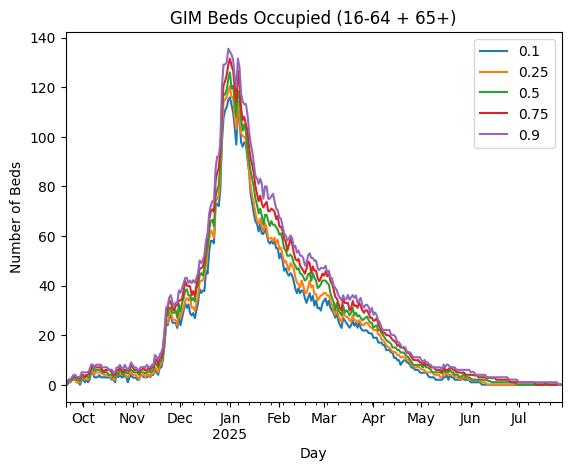

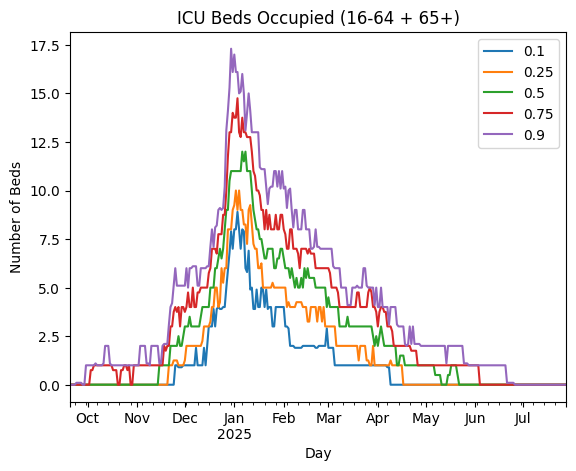

In [15]:
from matplotlib import pyplot as plt

from virus_sim_dashboard import sim

age_groups = ['0-15', '16-64', '65+']
chosen_groupings = age_groups
results = sim.sim_multiple(env_factory, 30, lambda x: None)

gim_summary = sim.get_quantiles(results.gim, chosen_groupings)
icu_summary = sim.get_quantiles(results.icu, chosen_groupings)

%matplotlib inline

gim_summary.plot(title="GIM Beds Occupied (16-64 + 65+)", ylabel="Number of Beds", xlabel="Day")
plt.show()

icu_summary.plot(title="ICU Beds Occupied (16-64 + 65+)", ylabel="Number of Beds", xlabel="Day")
plt.show()